In [1]:
print("hello world")

hello world


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Read Parquet").getOrCreate()

data = spark.read.parquet("data/yellow_tripdata_2026-05.parquet")
data.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/11 12:38:48 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/11 12:38:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/11 12:38:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [3]:
from pyspark.sql import functions as F
total_minutes_by_vendor = data.withColumn("duration_minute", F.timestamp_diff("MINUTE", "tpep_pickup_datetime", "tpep_dropoff_datetime"))
total_minutes_by_vendor = total_minutes_by_vendor.groupBy("PULocationID").agg(F.sum("duration_minute")).sort("PULocationID").withColumnRenamed("sum(duration_minute)", "total_mins")
total_fare_by_vendor = data.groupBy("PULocationID").agg(F.sum("total_amount")).sort("PULocationID")
total_fare_by_vendor = total_fare_by_vendor.withColumnRenamed("sum(total_amount)", "total_fares")
print(total_fare_by_vendor.columns)

['PULocationID', 'total_fares']


In [4]:
print(total_minutes_by_vendor.count())
total_minutes_by_vendor.show()

259
+------------+----------+
|PULocationID|total_mins|
+------------+----------+
|           1|       710|
|           2|       511|
|           3|     18580|
|           4|    299236|
|           6|      1644|
|           7|    180314|
|           8|       931|
|           9|      5699|
|          10|     80080|
|          11|     13111|
|          12|     22785|
|          13|    481126|
|          14|     71347|
|          15|      5568|
|          16|     13190|
|          17|    124043|
|          18|     44012|
|          19|     16013|
|          20|     22876|
|          21|     28925|
+------------+----------+
only showing top 20 rows


In [5]:
print(total_fare_by_vendor.count())
total_fare_by_vendor.show()

259
+------------+------------------+
|PULocationID|       total_fares|
+------------+------------------+
|           1| 57306.96000000005|
|           2|             630.8|
|           3|15509.510000000002|
|           4| 485524.9700000139|
|           6|           2840.74|
|           7| 264769.8600000013|
|           8|           2352.06|
|           9|           6261.93|
|          10|122457.29999999989|
|          11|          11517.58|
|          12|39045.240000000005|
|          13|  873797.880000002|
|          14| 66943.54000000001|
|          15| 5758.900000000001|
|          16|13273.710000000003|
|          17|140902.09000000008|
|          18|38165.939999999995|
|          19|          23044.89|
|          20|          21461.34|
|          21|          21931.41|
+------------+------------------+
only showing top 20 rows


In [6]:
joined_result = (total_minutes_by_vendor.join(total_fare_by_vendor, on="PULocationID").withColumn("revenue_per_min", F.col("total_fares") / F.col("total_mins"))
                 .select("PULocationID", "revenue_per_min"))

In [7]:
joined_result.show()

+------------+------------------+
|PULocationID|   revenue_per_min|
+------------+------------------+
|         148|1.7566531510982752|
|         243|1.5041685063758243|
|          31|1.3527600250626568|
|         137|1.5963082309390881|
|          85|0.9585209885516988|
|         251|1.6292266666666664|
|          65|1.4069852773826437|
|         255|1.6760178166401374|
|          53|1.2871066160035762|
|         133| 1.129045457768953|
|          78|0.8284095384878837|
|         155|0.8391504072945701|
|         108|0.7294367570862543|
|         211|1.6490804386044262|
|         193|1.4884333121803723|
|          34|1.7024027809179278|
|         101|1.1202820609251598|
|         126|1.1087011132268931|
|         115|1.7052075471698114|
|          81|0.8418627883872392|
+------------+------------------+
only showing top 20 rows


In [8]:
joined_result.sort("revenue_per_min").show()

+------------+------------------+
|PULocationID|   revenue_per_min|
+------------+------------------+
|         207|0.3848767313019389|
|         149|0.7227568922305765|
|         108|0.7294367570862543|
|         117|0.7393006880457077|
|          86|0.7404736732189929|
|          29|0.7425317826014546|
|         165|0.7432420450326497|
|          21|0.7582164217804667|
|         222|0.7618736548291628|
|         150|0.7643124249229645|
|          55|0.7709567731817286|
|          26|0.7722766024628986|
|         123|0.7769988849815594|
|          91|0.7856615740246116|
|         210|0.7876706622286656|
|         178|0.7948426666666666|
|          32|0.8028333119053743|
|         218|0.8073644598001674|
|         182|0.8081696624644159|
|         185|0.8099495442160853|
+------------+------------------+
only showing top 20 rows


In [15]:
joined_result.filter(joined_result.PULocationID == 207).show()

+------------+------------------+
|PULocationID|   revenue_per_min|
+------------+------------------+
|         207|0.3848767313019389|
+------------+------------------+



In [10]:
data.filter(data.PULocationID == 207).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2026-05-01 05:13:35|  2026-05-01 05:13:44|              1|          0.0|         1|                 N|         207|    

In [11]:
data2 = data
data2 = data2.withColumn("duration_second", F.timestamp_diff("SECOND", "tpep_pickup_datetime", "tpep_dropoff_datetime"))
data2.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+---------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|duration_second|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+---------------+
|       2| 2026-05-01 00:04:59|  2026-05-01 00:32:48|              1|         7.51

In [12]:
num_pickups = data2.groupby('PULocationID').count()
print('Zone 207 has', num_pickups.filter(num_pickups.PULocationID == 207).select('count').show())
num_pickups.show()

+-----+
|count|
+-----+
| 1068|
+-----+

Zone 207 has None
+------------+-----+
|PULocationID|count|
+------------+-----+
|         148|56529|
|         243| 4936|
|          31|   96|
|         137|47174|
|          85| 1511|
|         251|   13|
|          65| 5417|
|         255|10447|
|          53|  292|
|         133|  856|
|          78| 1056|
|         155| 1224|
|         108|  611|
|         211|33427|
|         193| 2872|
|          34|  783|
|         101|  270|
|         126|  760|
|         115|   22|
|          81|  741|
+------------+-----+
only showing top 20 rows


/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Text(0.5, 1.0, 'Number of pickups')

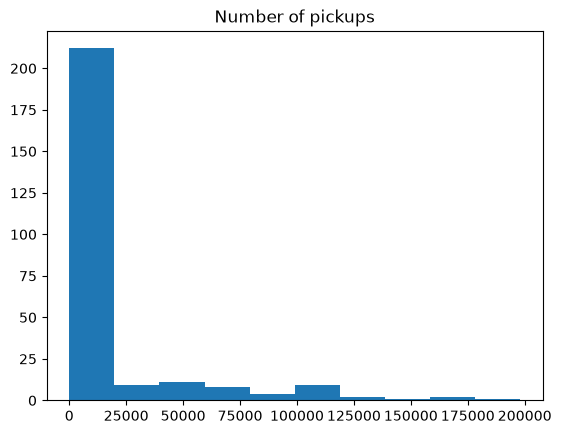

In [14]:
import matplotlib.pyplot as plt
plt.hist(num_pickups.toPandas()['count'], )
plt.title('Number of pickups')

In [21]:
from pyspark.sql.functions import col
zone_lookup = spark.read.csv('data/taxi_zone_lookup.csv', header=True)
zone_lookup = zone_lookup.withColumn('LocationID', col('LocationID').cast('int'))
zone_lookup.show()

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
|         6|Staten Island|Arrochar/Fort Wad...|   Boro Zone|
|         7|       Queens|             Astoria|   Boro Zone|
|         8|       Queens|        Astoria Park|   Boro Zone|
|         9|       Queens|          Auburndale|   Boro Zone|
|        10|       Queens|        Baisley Park|   Boro Zone|
|        11|     Brooklyn|          Bath Beach|   Boro Zone|
|        12|    Manhattan|        Battery Park| Yellow Zone|
|        13|    Manhattan|   Battery Park City| Yellow Zone|
|        14|     Brookly

In [37]:
row_vals = joined_result.limit(10).select('PULocationID').collect()
vals = [row["PULocationID"] for row in row_vals]
zone_lookup.filter(zone_lookup.LocationID.isin(vals)).show()

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|        31|        Bronx|          Bronx Park|   Boro Zone|
|        53|       Queens|       College Point|   Boro Zone|
|        65|     Brooklyn|Downtown Brooklyn...|   Boro Zone|
|        85|     Brooklyn|             Erasmus|   Boro Zone|
|       133|     Brooklyn|          Kensington|   Boro Zone|
|       137|    Manhattan|            Kips Bay| Yellow Zone|
|       148|    Manhattan|     Lower East Side| Yellow Zone|
|       243|    Manhattan|Washington Height...|   Boro Zone|
|       251|Staten Island|         Westerleigh|   Boro Zone|
|       255|     Brooklyn|Williamsburg (Nor...|   Boro Zone|
+----------+-------------+--------------------+------------+



In [39]:
import geopandas as gpd
taxi_zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")
print(taxi_zones.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


In [ ]:
taxi_zones.loc[taxi_zones.OBJECTID == 149].geometry.area

206    4.513711e+06
dtype: float64

<Axes: >

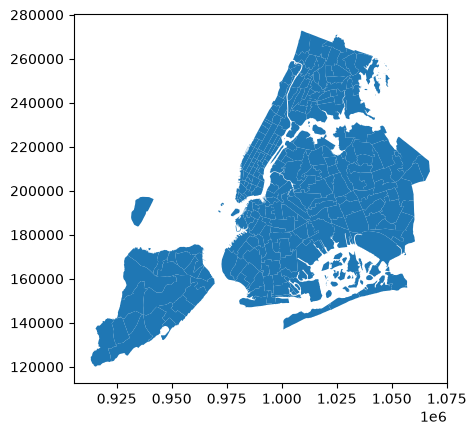

In [51]:
taxi_zones.plot()